In [13]:
import pandas as pd
df=pd.read_csv("data/raw.csv")
print(df.columns)

Index(['Age', 'Gender', 'Occupation', 'Device_Type', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'], dtype='str')


In [14]:
  
pd.set_option("display.width", 2000)         
print(df.head())

   Age  Gender      Occupation Device_Type  Daily_Phone_Hours  Social_Media_Hours  Work_Productivity_Score  Sleep_Hours  Stress_Level  App_Usage_Count  Caffeine_Intake_Cups  Weekend_Screen_Time_Hours
0   58    Male    Professional     Android                1.3                 6.7                        6          8.8         2.302               42                     1                        8.7
1   25    Male    Professional     Android                1.2                 1.5                        5          6.4         4.830               51                     3                        5.1
2   19    Male         Student         iOS                5.3                 5.7                        5          9.0         5.836               14                     5                        6.3
3   35  Female  Business Owner         iOS                5.8                 2.5                        2          5.7         5.827               36                     6                       12.8


In [15]:
print(df.shape)

(50000, 12)


In [16]:
print(df.isna().sum())

Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64


In [17]:
print(df.duplicated().sum())


0


In [18]:
print(df.describe())

                Age  Daily_Phone_Hours  Social_Media_Hours  Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  Caffeine_Intake_Cups  Weekend_Screen_Time_Hours
count  50000.000000       50000.000000        50000.000000             50000.000000  50000.000000  50000.000000      50000.00000          50000.000000               50000.000000
mean      39.034960           6.509116            4.267250                 5.503760      6.497744      4.949690         32.43898              3.004580                   8.006844
std       12.414877           3.170903            2.164743                 2.874806      1.449551      1.508862         16.12151              1.996657                   3.461300
min       18.000000           1.000000            0.500000                 1.000000      4.000000      0.000000          5.00000              0.000000                   2.000000
25%       28.000000           3.800000            2.400000                 3.000000      5.200000      3.85600

In [19]:
num_columns=df.select_dtypes(include=["number"]).columns
cat_columns=df.select_dtypes(exclude=["number"]).columns
print("num_columns=",num_columns)
print("cat_columns=",cat_columns)


num_columns= Index(['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'], dtype='str')
cat_columns= Index(['Gender', 'Occupation', 'Device_Type'], dtype='str')


In [20]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        50000 non-null  int64  
 1   Gender                     50000 non-null  str    
 2   Occupation                 50000 non-null  str    
 3   Device_Type                50000 non-null  str    
 4   Daily_Phone_Hours          50000 non-null  float64
 5   Social_Media_Hours         50000 non-null  float64
 6   Work_Productivity_Score    50000 non-null  int64  
 7   Sleep_Hours                50000 non-null  float64
 8   Stress_Level               50000 non-null  float64
 9   App_Usage_Count            50000 non-null  int64  
 10  Caffeine_Intake_Cups       50000 non-null  int64  
 11  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 4.6 MB
None


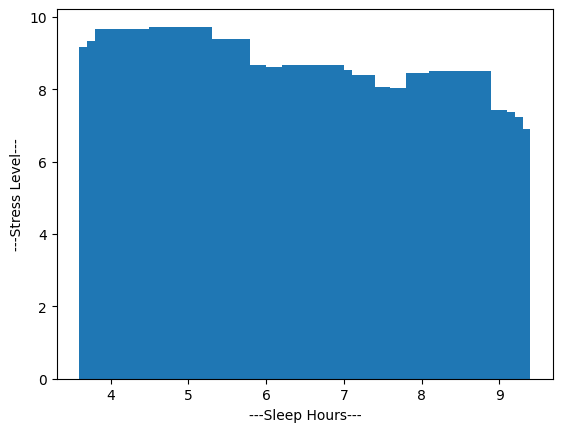

In [21]:
import matplotlib.pyplot as plt

df2=df.head(5000)

plt.bar(df2["Sleep_Hours"],df2["Stress_Level"])
plt.xlabel("---Sleep Hours---")
plt.ylabel("---Stress Level---")
plt.show()

~~ More sleep help to reduce Stress.



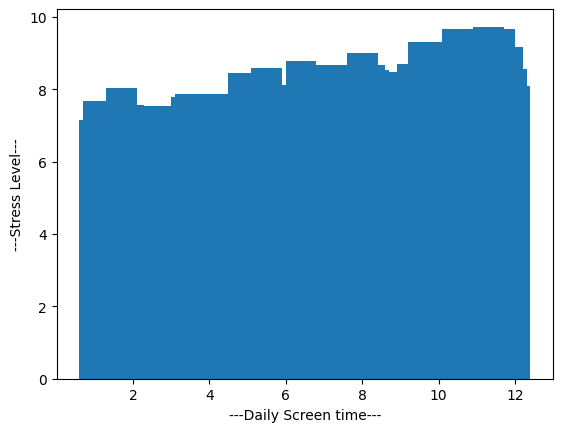

In [22]:
plt.bar(df2["Daily_Phone_Hours"],df2["Stress_Level"])
plt.xlabel("---Daily Screen time---")
plt.ylabel("---Stress Level---")
plt.show()

~~"Screen Time Increase Stress"

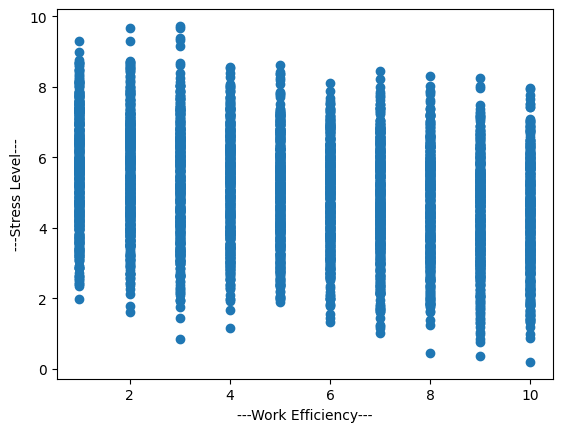

In [23]:
plt.scatter(df2["Work_Productivity_Score"],df2["Stress_Level"])
plt.xlabel("---Work Efficiency---")
plt.ylabel("---Stress Level---")
plt.show()

~~"High Stress Reduces Work Efficiency"

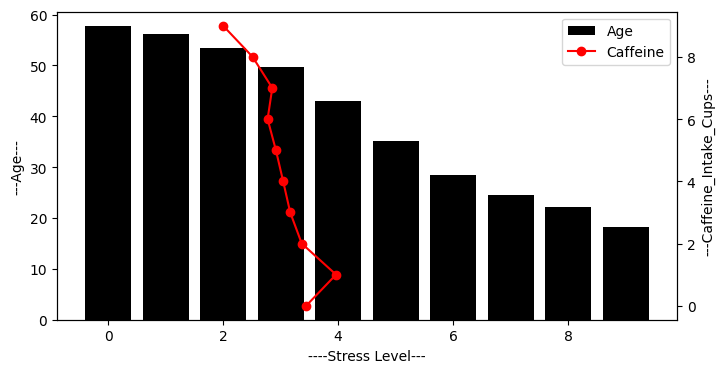

In [24]:
fig,axes=plt.subplots(figsize=(8,4))
df2["Stress"]=df2["Stress_Level"].astype(int)
ab=df2.groupby("Stress")["Age"].mean()
axes.bar(ab.index,ab.values,color="Black",label="Age")
axes.set_xlabel("----Stress Level---")
axes.set_ylabel("---Age---")

axes2=axes.twinx()
aa=df2.groupby("Stress")["Caffeine_Intake_Cups"].mean()
axes2.plot(aa.values,aa.index,color="Red",marker="o",label="Caffeine")
axes2.set_ylabel("---Caffeine_Intake_Cups---")

lines, labels = axes.get_legend_handles_labels()
lines2, labels2 = axes2.get_legend_handles_labels()
axes2.legend(lines + lines2, labels + labels2, loc="best")

plt.show()


- **Age vs Stress:**  
  The bar chart shows how age varies across different stress levels.  
  Older individuals tend to report lower stress compared to younger groups.

- **Caffeine Intake vs Stress:**  
  The line plot shows how average caffeine intake changes with stress levels.  
  In this dataset, higher caffeine consumption appears to be associated with lower stress